# Árvores de Decisão

Árvores de decisão consistem em um modelo preditivo em forma de árvore que particiona o espaço de características (*features*) por meio de testes condicionais sucessivos. Pode ser utilizados para classificação ou regressão.

## Implementação de uma Árvore de Decisão usando `sklearn`

Vamos implementar uma árvore de decisão utilizando a `sklearn`. Essa árvore será utilizada para classificar flor de iris. Inicialmente, vamos importar as bibliotecas:

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

Realizando algumas configurações nos plots:

In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

Importando nosso dataset:

In [3]:
iris = load_iris()
X, y = iris.data, iris.target

Realizando a divisão em conjunto de testes e treinamento. Lembrando que para árvores de decisão, não é necessário a normalização:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

Vamos criar nosso modelo de árvore:

In [9]:
model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,               # limita a profundidade (evita overfitting)
        min_samples_split=2,       # Mínimo de amostras necessárias para fazer um split
        min_samples_leaf=1,        # Mínimo de amostras para considerar um nó como folha
        random_state=42,
    )

E após isso, vamos treinar nosso modelo:

In [10]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Podemos visualizar a árvore utilizando a função `plot_tree`:

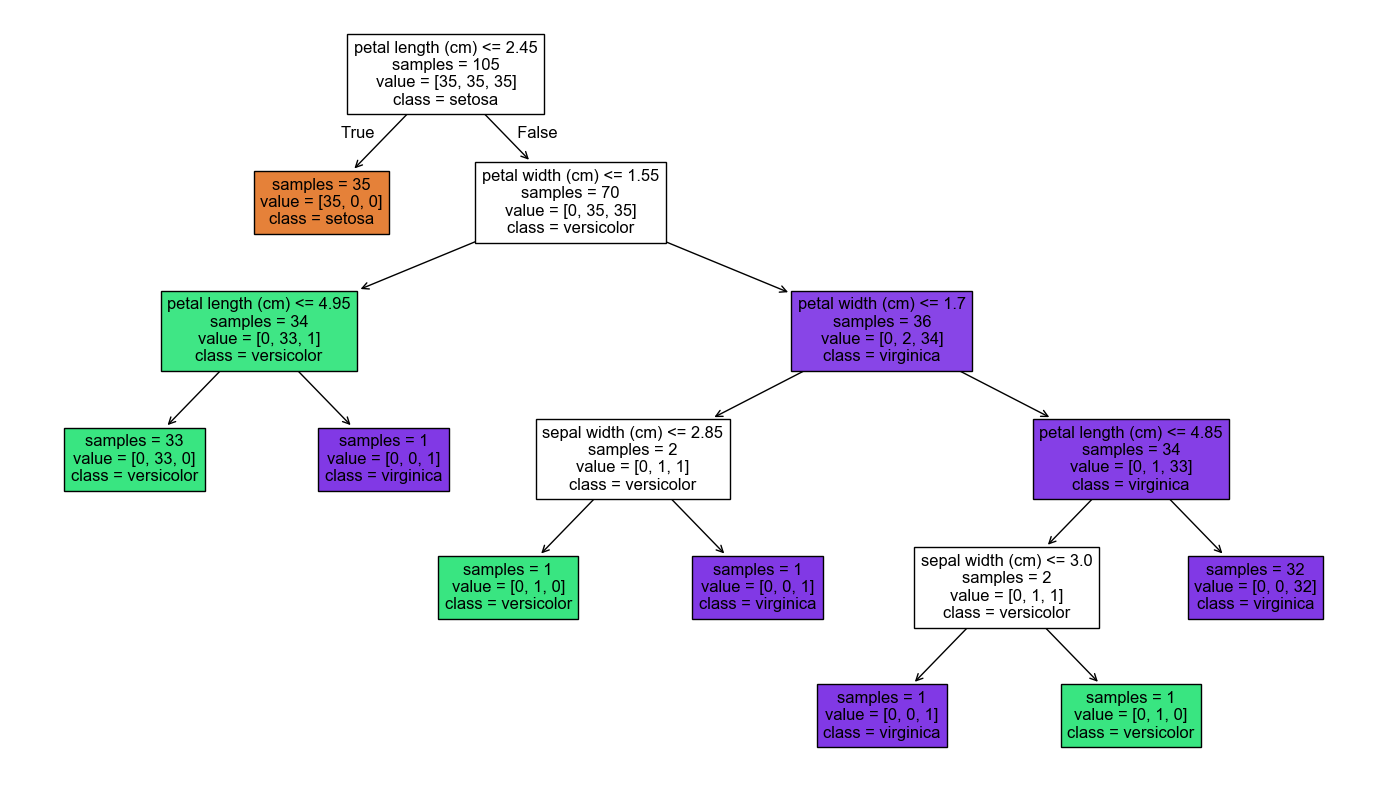

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(
        model,
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        impurity=False,
        ax=ax,
    )
fig.tight_layout()

Podemos também visualizar uma estrutura em forma de árvore textual utilizando a função `export_text`:

In [12]:
print(
    export_text(
        model, 
        feature_names=list(iris.feature_names),
        class_names=iris.target_names
    )
)

|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: versicolor
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: virginica
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |   |--- class: virginica
|   |   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |   |--- class: versicolor
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: virginica



Calculando a acurácia de classificação:

In [13]:
y_pred = model.predict(X_test)
print(f"Acurácia (teste):  {accuracy_score(y_test, y_pred):.4f}")

Acurácia (teste):  0.9333


Bem como a matriz de confusão:

In [15]:
print(iris.target_names)
print("\nMatriz de confusão (teste):")
print(confusion_matrix(y_test, y_pred))

['setosa' 'versicolor' 'virginica']

Matriz de confusão (teste):
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


## Implementação Manual

Vamos realizar a implementação manual de uma árvore de decisão. Inicialmente vamos importar as bibliotecas necessárias:

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from dataclasses import dataclass    # serve para gerar automaticamente o construtor
from typing import Optional          # serve para indicar que uma variável, argumento 
                                     # de função ou valor de retorno pode ser de um 
                                     # tipo específico ou None

Criando a classe para representar um nó:

In [2]:
@dataclass
class node:
    feature: Optional[int] = None    
    threshold: Optional[float] = None  
    left_branch: Optional["node"] = None      # ramo para onde vão os que responderam SIM (<=)
    right_branch: Optional["node"] = None     # ramo onde vão os que responderam NÃO (>)
    nameclass: Optional[int] = None           # se for folha, aqui fica a resposta

    def is_leaf(self) -> bool:
        return self.nameclass is not None      # Retorna verdadeiro se houver classe definida

E agora, a classe para representar nossa árvore de decisão, juntamente com os métodos necessários:

In [8]:
"""
    max_depth: Profundidade máxima permita pela árvore de decisão
    min_samples_split: Número mínimo de amostras num nó para tentar realizar o split.
                       Se o valor é muito pequeno, não adianta dividir
    criterion: Métrica para definir impureza. Pode ser 'gini' ou 'entropy'
"""
class decisionTree:
    """
        Construtor
    """
    def __init__(
        self,
        max_depth: Optional[int] = None,
        min_samples_split: int = 2,
        criterion: str = 'gini'
    ):
        if criterion not in {"gini", "entropy"}:
            raise ValueError("The criterion should be entropy or gini.")

        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.criterion = criterion

        # A árvore inicia vazia, apenas com o nó raiz
        self.root: Optional[node] = None

    """
        _impurity() -> Métrica para definir impureza
    """
    def _impurity(self, y: np.ndarray) -> float:
        if y.size == 0:
            return 0.0
            
        # Calcula quantas vezes uma classe aparece e determina a probabilidade
        _, counts = np.unique(y, return_counts = True)
        probs = counts/y.size

        # Calcula a métrica de impureza - gini ou entropia
        if self.criterion == "gini":
            return 1.0 - np.sum(probs**2)
        else:
            return -np.sum(probs * np.log2(probs + 1e-12))

    """
        _best_split() -> Determinar o melhor split
        Estratégia de força bruta:
        Para CADA feature:
            Para CADA valor possível de corte:
                Divide os dados em dois grupos (<=corte e >corte)
                Calcula a impureza dos dois grupos juntos
                Se ficou menor que a melhor até agora, guarda essa.
    """
    def _best_split(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        impurity_origin = self._impurity(y)

        best_imprt_gain = 0.0
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            # Pega todos os valores únicos dessa feature, já ordenados
            values = np.unique(X[:, feature])

            # Calcula o ponto médio entre dois valores consecutivos
            candidates_threshold = (values[:-1] + values[1:]) / 2.0

            # Agora testando para cada limiar candidato
            for thrs in candidates_threshold:
                # Criar uma máscara
                mask_left = X[:, feature] <= thrs
                
                # Quantos foram para esquerda (SIM) e para direita (NÃO)
                n_left = mask_left.sum()
                n_right = n_samples - n_left

                # Se um lado fica vazio, não serve
                if n_left == 0 or n_right == 0:
                    continue

                # Calcula a impureza dos dois conjuntos separados
                imprt_left = self._impurity(y[mask_left])
                imprt_right = self._impurity(y[~mask_left])

                # Impureza ponderada
                weighted_imprt = (n_left*imprt_left + n_right*imprt_right)/n_samples

                # Calcula o ganho
                imprt_gain = impurity_origin - weighted_imprt

                # Se for o melhor ganho até agora, guarda essa divisão
                if imprt_gain > best_imprt_gain:
                    best_imprt_gain = imprt_gain
                    best_feature = feature
                    best_threshold = thrs

        return best_feature, best_threshold, best_imprt_gain

    """
        _majority_class() -> Retorna a classe majoritária em um vetor de valores
    """
    def _majority_class(self, y: np.ndarray) -> int:
        values, counters = np.unique(y, return_counts=True)
        idx_max = np.argmax(counters)
        return values[idx_max]

    """
        _build() -> Construir a árvore de forma recursiva
    """
    def _build(self, X: np.ndarray, y: np.ndarray, depth:int) -> node:
        # Critérios de Parada
        # 1. Todos os elementos pertencem a mesma classe?
        # 2. Atingiu a quantidade mínima de amostras para o split?
        # 3. Já atingiu a profundidade máxima?
        # Se sim, retorna um nó com a classe majoritária
        if (
            len(np.unique(y)) == 1
            or len(y) < self.min_samples
            or (self.max_depth is not None and depth >= self.max_depth)
        ):
            return node(nameclass = self._majority_class(y))

        # Encontra a melhor divisao
        feature, thrsh, imprt_gain = self._best_split(X, y)

        # Se não há divisão útil, cria folha
        if feature is None or imprt_gain == 0.0:
            return node(nameclass = self._majority_class(y))

        # Se não (há uma divisão válida), então divide os árvores e inicia a recurssão
        mask_left = X[:, feature] <= thrsh
        left_branch = self._build(X[mask_left], y[mask_left], depth + 1)
        right_branch = self._build(X[~mask_left], y[~mask_left], depth + 1)

        # Retorna um nó interno com a pergunta e os dois ramos
        return node(
            feature = feature, 
            threshold = thrsh, 
            left_branch = left_branch, 
            right_branch = right_branch
        )

    """
        fit() --> Serve para treinar o algoritmo
    """
    def fit(self, X: np.ndarray, y: np.ndarray) -> "decisionTree":
        X, y = np.asarray(X), np.asarray(y)

        # Constroi a árvore inteira, iniciando do nível 0 (raiz)
        self.root = self._build(X, y, depth = 0)

        return self

    """
        _predict_sample() --> Prevê uma amostra
    """
    def _predict_sample(self, x: np.ndarray, no: node) -> int:
        if no.is_leaf():
            return no.nameclass
        if x[no.feature] <= no.threshold:
            return self._predict_sample(x, no.left_branch)
        return self._predict_sample(x, no.right_branch)

    """
        predict() --> Prevê um conjunto de amostras
    """
    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        return np.array([self._predict_sample(x, self.root) for x in X])

    """
        pretty_print() --> Imprimir a árvore de decisão de forma textual
    """
    def pretty_print(self,
                     name_features: Optional[list[str]] = None,
                     class_names:   Optional[list[str]] = None) -> None:
    
        def _label(no: node) -> str:
            if no.is_leaf():
                cls = class_names[no.nameclass] if class_names is not None else no.nameclass
                return f"class = {cls}"
            name = name_features[no.feature] if name_features else f"x[{no.feature}]"
            return f"{name} <= {no.threshold:.4f}"
    
        def _aux(no: node, prefix: str = "") -> None:
            if no.is_leaf():
                return
            children = [(no.left_branch, "yes"), (no.right_branch, "no ")]
            for i, (child, branch) in enumerate(children):
                is_last = (i == len(children) - 1)
                connector    = "└── " if is_last else "├── "
                child_prefix = prefix + ("    " if is_last else "│   ")
                print(f"{prefix}{connector}{branch}: {_label(child)}")
                _aux(child, child_prefix)
    
        if self.root is None:
            print("Decision tree that has not yet been trained.")
            return
        print(_label(self.root))
        _aux(self.root)
        

Após isso, vamos treinar nossa árvore para o mesmo dataset do exemplo anterior:

In [9]:
# from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

Criando o modelo e realizando o treinamento:

In [10]:
model_handcraft = decisionTree(max_depth = 5, criterion = "gini")
model_handcraft.fit(X_train, y_train)

Vamos imprimir a árvore gerada:

In [11]:
model_handcraft.pretty_print(
    name_features=list(iris.feature_names), 
    class_names=list(iris.target_names)
)

petal length (cm) <= 2.4500
├── yes: class = setosa
└── no : petal width (cm) <= 1.5500
    ├── yes: petal length (cm) <= 4.9500
    │   ├── yes: class = versicolor
    │   └── no : class = virginica
    └── no : petal length (cm) <= 4.8500
        ├── yes: sepal length (cm) <= 6.0500
        │   ├── yes: class = versicolor
        │   └── no : class = virginica
        └── no : petal width (cm) <= 1.7000
            ├── yes: sepal length (cm) <= 6.6000
            │   ├── yes: class = versicolor
            │   └── no : class = virginica
            └── no : class = virginica


Vamos avaliar a acurácia:

In [12]:
y_pred = model_handcraft.predict(X_test)
print(f"Acurácia (teste):  {accuracy_score(y_test, y_pred):.4f}")

Acurácia (teste):  0.9111


E a matriz de confusão:

In [13]:
print("\nMatriz de confusão (teste):")
print(confusion_matrix(y_test, y_pred))


Matriz de confusão (teste):
[[15  0  0]
 [ 0 13  2]
 [ 0  2 13]]
